# Board Reporting Automation — Paju Consumer Products Oy

**This dataset is synthetic, engineered with a held-out answer key.** Paju Consumer
Products Oy is a fictional Nordic personal-care and home-care manufacturer; every
table in `data/` is generated by `code/generate_financials.py` from `code/config.py`
(seed 42, fully reproducible) — see `design/design.md` for the full design and
`design/DECISIONS.md` for the build log. Four "stories" are planted in the data on
purpose: mechanics, timing, affected entities and designed magnitude are all fixed in
advance and checked by `code/validate_financials.py` before anything downstream runs.
One of the four is a trap — a number that looks alarming and isn't. The point of
building it this way is that we can *mark* what an analysis layer finds and misses,
rather than assert it.

**What this notebook shows, in order:**

1. The company, from the public data alone (§1).
2. **The pack** — `code/variance_analysis.py`, a deterministic variance-analysis layer
   that reads the public CSVs and states *what* moved, never *why* (§2).
3. The four planted stories against the pack's output: one trap the pack must not cry
   wolf on (§3), and three real stories it either explains correctly or fails to
   surface at all (§4–§6).
4. **The storytellers** — three independent AI agent runs given the pack and the raw
   data (never the answer key) and asked to explain the flags and surface what the
   pack missed — and the marking against the answer key (§7).
5. What a board does with the result (§8), and how to reproduce all of it (§9).

The answer key (`data/answer_key/stories.csv`) is loaded in exactly one place in this
notebook — §7 — mirroring how the evaluation pipeline itself only touches it at
marking time. Sections 1–6 work from the public CSVs and the pack's own output, plus
one clearly labelled exception in §6 where a single exhibit needs the data generator's
internal driver model to compute a counterfactual (disclosed there in full).

In [1]:
# Global style -- matplotlib only. Modest figures, solid fills, minimal chartjunk.
# Chart palette validated 3 Jul 2026 via the Hapax dataviz procedure (brand-derived
# tints, not the raw brand tokens -- the raw tokens fail the lightness/chroma checks
# against this notebook's figure face). Fixed identity per chart, never cycled:
#   WINE   = primary "actual" / headline series
#   INDIGO = secondary comparison series
#   GOLD   = tertiary series (reserved; unused unless a chart needs a third mark colour)
#   GREY   = context / reference series (budget, baselines) -- always direct-labelled
#   INK    = text                       BEIGE = fills / bands
import sys
import json
import calendar
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown

WINE   = "#A8352A"
INDIGO = "#41529E"
GOLD   = "#B68A2C"
GREY   = "#665E58"
INK    = "#1A1410"
BEIGE  = "#EFE5CE"
FIG_FACE = "#FBFAF5"

# Titles in Cormorant Garamond if installed on this machine; silent serif fallback
# otherwise (never install fonts from a notebook).
_available_fonts = {f.name for f in fm.fontManager.ttflist}
TITLE_FONT = "Cormorant Garamond" if "Cormorant Garamond" in _available_fonts else "serif"
print(f"Title font: {TITLE_FONT}" + ("" if TITLE_FONT != "serif" else "  (Cormorant Garamond not found -- falling back silently)"))

FIG_SIZE = (7.0, 3.5)
DPI = 130

plt.rcParams.update({
    "figure.facecolor": FIG_FACE,
    "axes.facecolor": FIG_FACE,
    "savefig.facecolor": FIG_FACE,
    "axes.edgecolor": GREY,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": GREY,
    "ytick.color": GREY,
    "font.size": 9,
    "axes.grid": True,
    "grid.color": BEIGE,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.axisbelow": True,
    "axes.linewidth": 0.8,
})


def new_fig(figsize=FIG_SIZE):
    """One y-axis, light y-grid only, minimal left/bottom spines."""
    fig, ax = plt.subplots(figsize=figsize, dpi=DPI)
    ax.grid(axis="y", zorder=0)
    ax.grid(axis="x", visible=False)
    return fig, ax


def style_title(ax, text):
    ax.set_title(text, fontsize=12.5, fontfamily=TITLE_FONT, color=INK, loc="left", pad=10)


def eur_fmt(x, pos=None):
    """EUR k / EUR M tick formatter."""
    if abs(x) >= 1_000_000:
        return f"€{x/1_000_000:,.1f}M".replace(".0M", "M")
    if abs(x) >= 1_000:
        return f"€{x/1_000:,.0f}k"
    return f"€{x:,.0f}"


def pct_fmt(x, pos=None):
    return f"{x:.0f}%"


MONTH_NAMES = {i: calendar.month_abbr[i] for i in range(1, 13)}


def month_label(month: str) -> str:
    y, m = int(month[:4]), int(month[5:7])
    return f"{MONTH_NAMES[m]} {y}"


def month_tick_setup(ax, months, every="semiannual"):
    """Ticks at January and July of each year (or every month if <= 6 months)."""
    if every == "semiannual":
        idx = [i for i, m in enumerate(months) if m.endswith("-01") or m.endswith("-07")]
    else:
        idx = list(range(len(months)))
    ax.set_xticks(idx)
    ax.set_xticklabels([month_label(months[i]) for i in idx], fontsize=8)
    ax.set_xlim(-0.5, len(months) - 0.5)


def end_label(ax, x, y, text, color, offset=(9, 0), fontsize=8.5, ha="left"):
    """Direct/end-of-line label. dataviz anti-pattern: "text never wears the data
    color" -- a colored mark (here, a small dot at the line's end) carries series
    identity; the label text itself always stays in Ink."""
    ax.scatter([x], [y], s=24, color=color, zorder=6, clip_on=False)
    ax.annotate(text, xy=(x, y), xytext=offset, textcoords="offset points",
                fontsize=fontsize, color=INK, va="center", ha=ha, fontweight="normal", zorder=6)


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ANALYSIS_DIR = DATA_DIR / "analysis"
CODE_DIR = PROJECT_ROOT / "code"
ANSWER_KEY_DIR = DATA_DIR / "answer_key"

assert DATA_DIR.exists(), f"data dir not found at {DATA_DIR} -- run this notebook from notebooks/ or the project root"
print(f"Project root resolved to: {PROJECT_ROOT}")

EUR_TOL = 10_000   # matches evaluation_worksheet.md SS E's stated tolerance
PCT_TOL = 0.1      # matches evaluation_worksheet.md SS E's stated tolerance

Title font: Cormorant Garamond
Project root resolved to: C:\Users\luigi\Dropbox\Archivio famiglia\Hapax\Case Studies\05 Board Reporting


## 1. The company at a glance

Paju Consumer Products Oy sells personal-care and home-care products through grocery
and pharmacy retail across Northern Europe, plus a professional channel, from three
business units (Nordics, Central Europe, Baltics & Poland) and four product lines
(Hair Care, Skin & Body, Home Care, Professional). Everything below this cell is
computed from the nine public CSVs only.

In [2]:
# Load the nine public data tables -- nothing under data/answer_key/ is touched here.
pnl = pd.read_csv(DATA_DIR / "pnl_monthly.csv")
budget_pnl = pd.read_csv(DATA_DIR / "budget_pnl_monthly.csv")
opex = pd.read_csv(DATA_DIR / "opex_monthly.csv")
budget_opex = pd.read_csv(DATA_DIR / "budget_opex_monthly.csv")
customer_master = pd.read_csv(DATA_DIR / "customer_master.csv")
customer_revenue = pd.read_csv(DATA_DIR / "customer_revenue_monthly.csv")
working_capital = pd.read_csv(DATA_DIR / "working_capital_monthly.csv")
receivables_by_customer = pd.read_csv(DATA_DIR / "receivables_by_customer_monthly.csv")
cash = pd.read_csv(DATA_DIR / "cash_monthly.csv")

public_tables = {
    "pnl_monthly": pnl, "budget_pnl_monthly": budget_pnl,
    "opex_monthly": opex, "budget_opex_monthly": budget_opex,
    "customer_master": customer_master, "customer_revenue_monthly": customer_revenue,
    "working_capital_monthly": working_capital,
    "receivables_by_customer_monthly": receivables_by_customer, "cash_monthly": cash,
}
for name, df in public_tables.items():
    print(f"  {name}.csv: {len(df):,} rows")

  pnl_monthly.csv: 288 rows
  budget_pnl_monthly.csv: 288 rows
  opex_monthly.csv: 72 rows
  budget_opex_monthly.csv: 72 rows
  customer_master.csv: 33 rows
  customer_revenue_monthly.csv: 792 rows
  working_capital_monthly.csv: 72 rows
  receivables_by_customer_monthly.csv: 792 rows
  cash_monthly.csv: 24 rows


In [3]:
# Headline table, FY2024 vs FY2025 -- company grain, from pnl_monthly + opex_monthly.

def fy(df, year, col="month"):
    return df[df[col].str.startswith(year)]

rev_fy24 = fy(pnl, "2024")["net_revenue"].sum()
rev_fy25 = fy(pnl, "2025")["net_revenue"].sum()
growth_pct = (rev_fy25 / rev_fy24 - 1) * 100

gp_fy24 = fy(pnl, "2024")["gross_profit"].sum()
gp_fy25 = fy(pnl, "2025")["gross_profit"].sum()
gm_fy24 = gp_fy24 / rev_fy24 * 100
gm_fy25 = gp_fy25 / rev_fy25 * 100

gp_by_month = pnl.groupby("month")["gross_profit"].sum()
sm_by_month = opex.groupby("month")["sales_marketing"].sum()
admin_by_month = opex.groupby("month")["admin_general"].sum()
oi_by_month = opex.groupby("month")["other_income"].sum()
ebitda_reported_by_month = gp_by_month - sm_by_month - admin_by_month + oi_by_month

ebitda_fy24 = ebitda_reported_by_month[ebitda_reported_by_month.index.str.startswith("2024")].sum()
ebitda_fy25 = ebitda_reported_by_month[ebitda_reported_by_month.index.str.startswith("2025")].sum()
oi_fy24 = oi_by_month[oi_by_month.index.str.startswith("2024")].sum()
oi_fy25 = oi_by_month[oi_by_month.index.str.startswith("2025")].sum()
ebitda_underlying_fy24 = ebitda_fy24 - oi_fy24
ebitda_underlying_fy25 = ebitda_fy25 - oi_fy25

# DSO (December, trailing-12-month average daily net revenue) and revenue per head,
# company grain -- same convention as code/variance_analysis.py's compute_dso /
# compute_revenue_per_head, recomputed here directly from the public CSVs.

def days_in_month(month):
    y, m = int(month[:4]), int(month[5:7])
    return calendar.monthrange(y, m)[1]

wc_company = working_capital.groupby("month", as_index=False)[
    ["receivables_opening", "collections", "receivables_closing"]
].sum().set_index("month")
rev_by_month = pnl.groupby("month")["net_revenue"].sum()
hc_by_month = opex.groupby("month")["headcount_fte"].sum()
months_sorted = sorted(rev_by_month.index)

def trailing_window(target_month, window=12):
    i = months_sorted.index(target_month)
    return months_sorted[max(0, i - window + 1): i + 1]

def dso_trailing12(target_month):
    window = trailing_window(target_month)
    total_rev = rev_by_month.loc[window].sum()
    total_days = sum(days_in_month(m) for m in window)
    avg_daily = total_rev / total_days
    return wc_company.loc[target_month, "receivables_closing"] / avg_daily

def revenue_per_head_trailing12(target_month):
    window = trailing_window(target_month)
    total_rev = rev_by_month.loc[window].sum()
    total_days = sum(days_in_month(m) for m in window)
    avg_hc = hc_by_month.loc[window].mean()
    annualised_rev = total_rev / total_days * 365
    return annualised_rev / avg_hc

dso_dec24 = dso_trailing12("2024-12")
dso_dec25 = dso_trailing12("2025-12")
rph_dec24 = revenue_per_head_trailing12("2024-12")
rph_dec25 = revenue_per_head_trailing12("2025-12")

headline = pd.DataFrame({
    "FY2024": [rev_fy24, None, gm_fy24, ebitda_fy24, ebitda_underlying_fy24, dso_dec24, rph_dec24],
    "FY2025": [rev_fy25, growth_pct, gm_fy25, ebitda_fy25, ebitda_underlying_fy25, dso_dec25, rph_dec25],
}, index=["Net revenue (EUR)", "Growth YoY (%)", "Gross margin (%)",
          "EBITDA reported (EUR)", "EBITDA underlying (EUR)",
          "DSO, December, trailing-12 (days)", "Revenue per head, trailing-12 (EUR)"])
display(headline.style.format("{:,.2f}", na_rep="--"))

# Anchor asserts -- evaluation_worksheet.md SS E, "recomputed fresh from the public
# CSVs on every run of this script -- never hardcoded". Tolerances as stated there.
assert abs(rev_fy24 - 154_680_645.51) < EUR_TOL, "FY24 revenue anchor failed"
assert abs(rev_fy25 - 168_028_808.07) < EUR_TOL, "FY25 revenue anchor failed"
assert abs(growth_pct - 8.63) < PCT_TOL, "FY25 growth anchor failed"
assert abs(gm_fy24 - 42.54) < PCT_TOL, "FY24 GM anchor failed"
assert abs(gm_fy25 - 40.23) < PCT_TOL, "FY25 GM anchor failed"
assert abs(ebitda_fy24 - 17_956_325.27) < EUR_TOL, "FY24 reported EBITDA anchor failed"
assert abs(ebitda_fy25 - 17_697_896.35) < EUR_TOL, "FY25 reported EBITDA anchor failed"
assert abs(ebitda_underlying_fy25 - 15_497_896.35) < EUR_TOL, "FY25 underlying EBITDA anchor failed"
print("\nAll SS E anchor asserts passed (revenue, growth, GM%, EBITDA reported/underlying).")

,FY2024,FY2025
Net revenue (EUR),"154,680,645.51","168,028,808.07"
Growth YoY (%),--,8.63
Gross margin (%),42.54,40.23
EBITDA reported (EUR),"17,956,325.27","17,697,896.35"
EBITDA underlying (EUR),"17,956,325.27","15,497,896.35"
"DSO, December, trailing-12 (days)",41.81,46.77
"Revenue per head, trailing-12 (EUR)","318,879.63","340,598.94"



All SS E anchor asserts passed (revenue, growth, GM%, EBITDA reported/underlying).


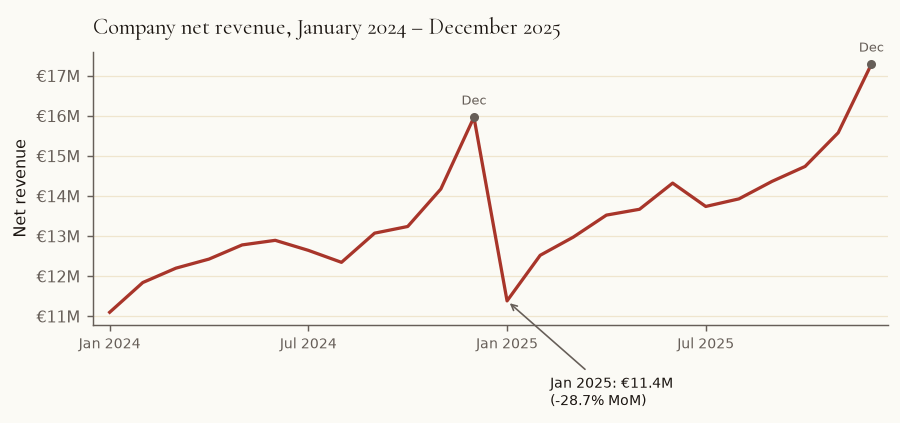

In [4]:
# Chart 1 -- company monthly net revenue, 24 months, single Wine line, no legend.
company_month = pnl.groupby("month", as_index=False)["net_revenue"].sum().sort_values("month")
months = company_month["month"].tolist()
values = company_month["net_revenue"].tolist()

fig, ax = new_fig()
x = list(range(len(months)))
ax.plot(x, values, color=WINE, linewidth=1.8, zorder=3)

dec_idx = [i for i, m in enumerate(months) if m.endswith("-12")]
ax.scatter(dec_idx, [values[i] for i in dec_idx], color=GREY, s=16, zorder=4)
for i in dec_idx:
    ax.annotate("Dec", (i, values[i]), textcoords="offset points", xytext=(0, 7),
                fontsize=7, color=GREY, ha="center")

jan25_i = months.index("2025-01")
jan25_mom = (values[jan25_i] / values[jan25_i - 1] - 1) * 100
ax.annotate(
    f"Jan 2025: {eur_fmt(values[jan25_i])}\n({jan25_mom:+.1f}% MoM)",
    xy=(jan25_i, values[jan25_i]), xytext=(jan25_i + 1.3, values[jan25_i] - 2_600_000),
    fontsize=8, color=INK,
    arrowprops=dict(arrowstyle="->", color=GREY, lw=0.9),
)

ax.set_ylabel("Net revenue")
ax.yaxis.set_major_formatter(FuncFormatter(eur_fmt))
month_tick_setup(ax, months)
style_title(ax, "Company net revenue, January 2024 – December 2025")
plt.tight_layout()
plt.show()

Everything that follows starts from this shape: two Decembers of gifting-season peaks,
two January troughs, and a company that grew net revenue 8.6% year on year underneath
that seasonal pattern. Section 3 returns to the January drop; sections 4–6 explain what
sits beneath the FY2025 growth number.

## 2. The pack (deterministic layer)

`code/variance_analysis.py` reads only the public CSVs -- never `code/config.py`,
never the answer key -- and produces the board pack: budget-vs-actual and
year-on-year variance tables, a KPI series, a price/volume/mix bridge, and mechanical
threshold flags. It states *what* moved, with numbers, and never *why* -- no causal
language ("driven by", "due to", "because") appears anywhere in its output. Its own
methodology block, verbatim:

In [5]:
# Print the pack's methodology block verbatim from its own output file.
surface_report_text = (ANALYSIS_DIR / "surface_report.md").read_text(encoding="utf-8")
start = surface_report_text.index("## Methodology and thresholds")
end = surface_report_text.index("## FY2024 baseline")
methodology_block = surface_report_text[start:end].rstrip()
display(Markdown(methodology_block))

## Methodology and thresholds

A cell is flagged when it breaches **either** the percentage band **or** the absolute-euro floor below, whichever is looser for that grain. Company-grain floors are higher than BU-grain floors because the company total is roughly the sum of three BUs. EBITDA carries a wider percentage band and a lower euro floor than the three revenue-line measures because it is a thin residual margin, structurally more volatile in percentage terms (operating leverage) -- a property of the measure, fixed before any figure below was generated.

| Measure | Basis | % threshold | Company € floor | BU € floor |
|---|---|---|---|---|
| net_revenue | MoM | 10% | €500,000 | €200,000 |
| net_revenue | YoY | 5% | €400,000 | €150,000 |
| net_revenue | vs_budget | 3% | €300,000 | €150,000 |
| gross_profit | MoM | 10% | €500,000 | €200,000 |
| gross_profit | YoY | 5% | €400,000 | €150,000 |
| gross_profit | vs_budget | 3% | €300,000 | €150,000 |
| material_cost | MoM | 10% | €500,000 | €200,000 |
| material_cost | YoY | 5% | €400,000 | €150,000 |
| material_cost | vs_budget | 3% | €300,000 | €150,000 |
| EBITDA | MoM | 20% | €200,000 | €100,000 |
| EBITDA | YoY | 15% | €200,000 | €100,000 |
| EBITDA | vs_budget | 8% | €150,000 | €75,000 |

DSO (receivables_closing ÷ trailing-12-month average daily net revenue) is flagged only year-on-year, same calendar month, when it worsens by more than 5 days -- receivables in this dataset build seasonally into December and unwind in Q1 (visible directly in `working_capital_monthly.csv`), so a month-on-month DSO threshold would flag the calendar, not a change in payment behaviour. The trailing window is partial (fewer than 12 months of history) for 2024-01 through 2024-11, since the public dataset starts 2024-01; those DSO figures are shown with the window length noted.

Revenue per head is the trailing-window average daily company net revenue, annualised at 365 days, divided by average headcount over the same window (same partial-window caveat as DSO).

Year-on-year variances are not computable for calendar-2024 months: the public dataset has no 2023 actuals or budget. 2024-01 has no month-on-month comparator for the same reason. Both are omitted from the tables below rather than shown as a false zero.

EBITDA is reported EBITDA (gross profit less sales & marketing less admin, plus other income) throughout the variance table and the flag thresholds. Underlying EBITDA (reported less other income) is shown alongside it in the KPI series and in the monthly narrative only for months where other income is non-zero -- other income is zero every month except where a one-off is booked, so any non-zero month is a one-off by construction. Showing the split draws no conclusion about which figure is more representative.

In [6]:
# Flag counts by measure x basis, 2025 (the year with a prior-year comparator) --
# from the pack's own tidy output, variances_monthly.csv.
variances = pd.read_csv(ANALYSIS_DIR / "variances_monthly.csv")
v2025 = variances[variances["month"].str.startswith("2025")]
flag_counts = (
    v2025[v2025["flag"]]
    .groupby(["measure", "basis"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["net_revenue", "gross_profit", "material_cost", "EBITDA"],
             columns=["MoM", "YoY", "vs_budget"])
)
flag_counts["Total"] = flag_counts.sum(axis=1)
print(f"{int(v2025['flag'].sum())} measure x basis threshold breaches across 2025 "
      f"(company + 3 BU grains; DSO YoY flags are computed separately by the pack "
      f"and are not part of this measure x basis table).")
display(flag_counts)

313 measure x basis threshold breaches across 2025 (company + 3 BU grains; DSO YoY flags are computed separately by the pack and are not part of this measure x basis table).


basis,MoM,YoY,vs_budget,Total
measure,,,,
net_revenue,23,37,23,83
gross_profit,10,27,38,75
material_cost,11,33,33,77
EBITDA,13,28,37,78


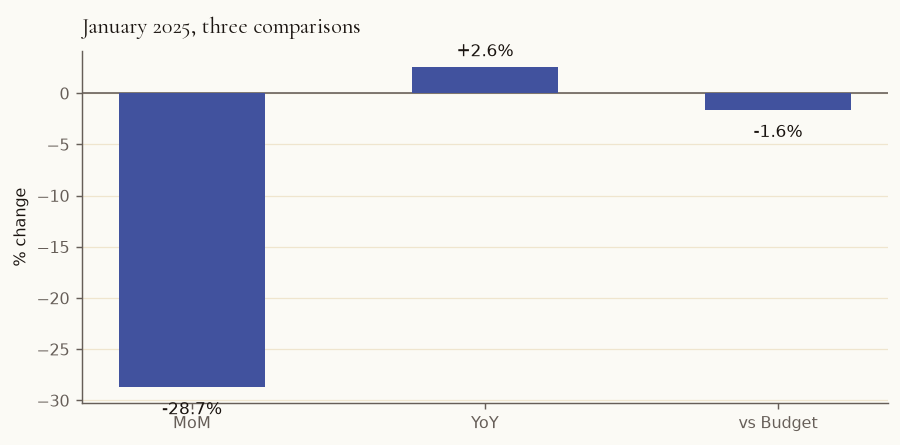

In [7]:
# Chart 2 -- "January 2025, three comparisons": three bars around a zero baseline,
# single Indigo, direct labels, no legend (one series -- the comparator changes,
# the measure does not).
jan_var_ch2 = variances[(variances.month == "2025-01") & (variances.grain == "Company")
                         & (variances.measure == "net_revenue")]
basis_order = ["MoM", "YoY", "vs_budget"]
basis_labels = ["MoM", "YoY", "vs Budget"]
ch2_vals = [jan_var_ch2[jan_var_ch2.basis == b]["pct"].iloc[0] for b in basis_order]

fig, ax = new_fig()
bars = ax.bar(basis_labels, ch2_vals, color=INDIGO, width=0.5, zorder=3)
ax.axhline(0, color=GREY, linewidth=0.9, zorder=2)
for b, v in zip(bars, ch2_vals):
    ax.annotate(f"{v:+.1f}%", (b.get_x() + b.get_width() / 2, v), textcoords="offset points",
                xytext=(0, 6 if v >= 0 else -15), ha="center", fontsize=9.5, color=INK)
ax.set_ylabel("% change")
style_title(ax, "January 2025, three comparisons")
plt.tight_layout()
plt.show()

## 3. S4 — the trap

Hair Care and Skin & Body carry a Q4 gifting peak and a Q1 trough, identical in both
years and in the budget. Every January, company net revenue drops steeply month on
month against the December peak -- and every January, that drop is exactly what the
seasonal build predicts. The pack must flag January (it breaches any honest MoM
threshold) but must not treat it as a crisis: the correct read is "stand down", and
all three storyteller runs said so (§7).

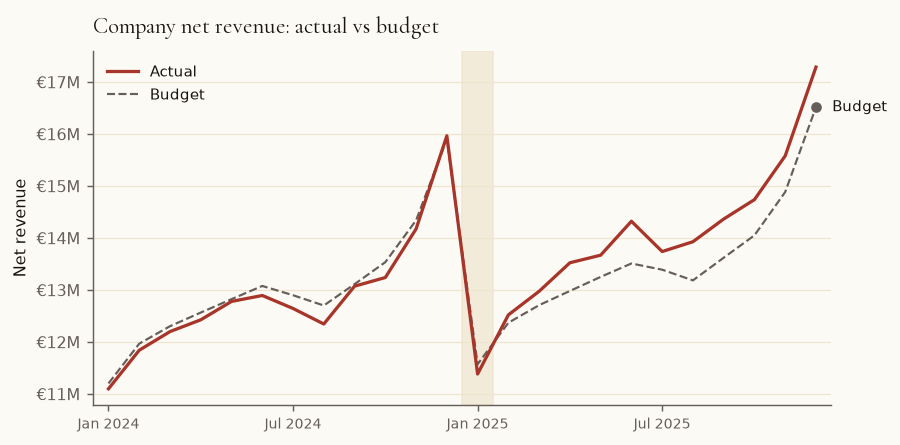

January 2025: -28.7% MoM, +2.6% YoY, -1.6% vs budget.


In [8]:
# Chart 3 -- monthly net revenue, actual (Wine) vs budget (Grey dashed, end-labelled),
# January 2025 highlighted in Beige.
budget_month = budget_pnl.groupby("month", as_index=False)["net_revenue"].sum().sort_values("month")
b_values = budget_month["net_revenue"].tolist()

fig, ax = new_fig()
x = list(range(len(months)))
ax.plot(x, values, color=WINE, linewidth=1.8, label="Actual", zorder=3)
ax.plot(x, b_values, color=GREY, linewidth=1.2, linestyle="--", label="Budget", zorder=2)

jan25_i = months.index("2025-01")
ax.axvspan(jan25_i - 0.5, jan25_i + 0.5, color=BEIGE, alpha=0.7, zorder=1)
ax.annotate("Jan 2025", xy=(jan25_i, min(values[jan25_i], b_values[jan25_i]) - 1_400_000),
            fontsize=8, color=INK, ha="center")

end_label(ax, x[-1], b_values[-1], "Budget", GREY)

ax.set_ylabel("Net revenue")
ax.yaxis.set_major_formatter(FuncFormatter(eur_fmt))
month_tick_setup(ax, months)
style_title(ax, "Company net revenue: actual vs budget")
ax.legend(loc="upper left", frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

jan_var = variances[(variances.month == "2025-01") & (variances.grain == "Company")
                     & (variances.measure == "net_revenue")]
mom = jan_var[jan_var.basis == "MoM"]["pct"].iloc[0]
yoy = jan_var[jan_var.basis == "YoY"]["pct"].iloc[0]
vs_budget = jan_var[jan_var.basis == "vs_budget"]["pct"].iloc[0]
print(f"January 2025: {mom:+.1f}% MoM, {yoy:+.1f}% YoY, {vs_budget:+.1f}% vs budget.")
assert abs(mom - (-28.7)) < 0.5 and abs(yoy - 2.6) < 0.5 and abs(vs_budget - (-1.6)) < 0.5

The budget line runs through the same December peak and January trough as the actual
line -- the budget was built from the same seasonal index (rule 10 of the validator:
the budget's seasonal index equals the generator's, so this alarm exists only in the
MoM view, never against budget or against prior year). January's MoM collapse is real
and the pack is right to flag it; but read against a comparator that understands the
calendar, January 2025 is unremarkable: up year on year, within 2% of budget. Standing
down here, correctly, is §7's easiest test and also its most important one -- a
storyteller that cries wolf on the trap loses credibility for everything else it says.

## 4. S1 — the mix shift that reads as input inflation

From February 2025, Nordics material costs run persistently above budget and above
prior year. The obvious commentary is input-cost inflation. It's the wrong story: unit
material costs barely move. What moves is the *mix* -- a promotional push shifts
volume into Home Care, the line with by far the heaviest material intensity (~48% of
net revenue vs a ~30% line average), at a deep promotional discount.

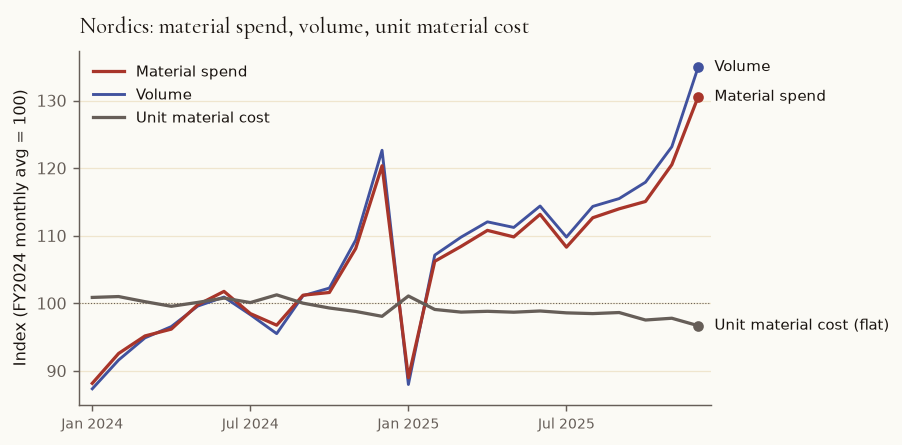

Nordics material spend, FY2025 vs FY2024: +11.53%


In [9]:
# Chart 4 -- Nordics, indexed to FY2024 monthly average = 100, one axis: material
# spend (Wine), volume (Indigo), unit material cost (Grey, flat -- the decisive line).
nordics = pnl[pnl.bu == "Nordics"]
nordics_month = nordics.groupby("month", as_index=False).agg(
    material_cost=("material_cost", "sum"), volume=("volume_units", "sum")
).sort_values("month")
nordics_month["unit_material_cost"] = nordics_month["material_cost"] / nordics_month["volume"]

base = nordics_month[nordics_month.month.str.startswith("2024")]
base_material, base_volume, base_unit = (
    base["material_cost"].mean(), base["volume"].mean(), base["unit_material_cost"].mean()
)
nordics_month["material_idx"] = nordics_month["material_cost"] / base_material * 100
nordics_month["volume_idx"] = nordics_month["volume"] / base_volume * 100
nordics_month["unit_idx"] = nordics_month["unit_material_cost"] / base_unit * 100

n_months = nordics_month["month"].tolist()
xn = list(range(len(n_months)))

fig, ax = new_fig()
ax.plot(xn, nordics_month["material_idx"], color=WINE, linewidth=1.8, label="Material spend", zorder=4)
ax.plot(xn, nordics_month["volume_idx"], color=INDIGO, linewidth=1.6, label="Volume", zorder=3)
ax.plot(xn, nordics_month["unit_idx"], color=GREY, linewidth=1.8, label="Unit material cost", zorder=5)
ax.axhline(100, color=GREY, linewidth=0.6, linestyle=":", zorder=1)

end_label(ax, xn[-1], nordics_month["material_idx"].iloc[-1], "Material spend", WINE)
end_label(ax, xn[-1], nordics_month["volume_idx"].iloc[-1], "Volume", INDIGO)
end_label(ax, xn[-1], nordics_month["unit_idx"].iloc[-1], "Unit material cost (flat)", GREY)

ax.set_ylabel("Index (FY2024 monthly avg = 100)")
month_tick_setup(ax, n_months)
style_title(ax, "Nordics: material spend, volume, unit material cost")
ax.legend(loc="upper left", frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

nordics_material_yoy = fy(nordics, "2025")["material_cost"].sum() / fy(nordics, "2024")["material_cost"].sum() * 100 - 100
print(f"Nordics material spend, FY2025 vs FY2024: {nordics_material_yoy:+.2f}%")
assert abs(nordics_material_yoy - 11.53) < 0.5

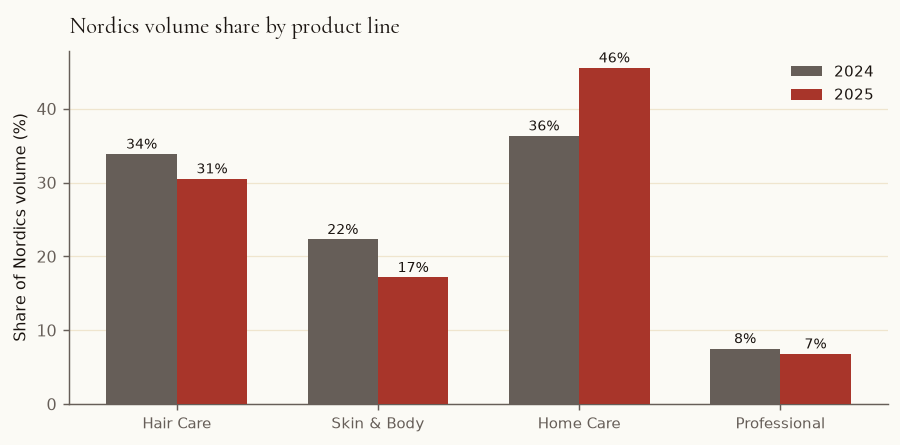

Home Care volume share: 36.3% (2024) -> 45.5% (2025)


In [10]:
# Chart 5 -- Nordics volume share by product line, 2024 vs 2025: grouped bars,
# x = line, colour = year (2024 Grey, 2025 Wine), % direct labels.
nordics_line = nordics.copy()
nordics_line["year"] = nordics_line["month"].str[:4]
share = nordics_line.groupby(["year", "line"])["volume_units"].sum().reset_index()
share["pct"] = share["volume_units"] / share.groupby("year")["volume_units"].transform("sum") * 100

line_order = ["Hair Care", "Skin & Body", "Home Care", "Professional"]
pivot = share.pivot(index="line", columns="year", values="pct").reindex(line_order)

fig, ax = new_fig()
xb = np.arange(len(line_order))
width = 0.35
bars24 = ax.bar(xb - width / 2, pivot["2024"], width, color=GREY, label="2024", zorder=3)
bars25 = ax.bar(xb + width / 2, pivot["2025"], width, color=WINE, label="2025", zorder=3)
for b in list(bars24) + list(bars25):
    ax.annotate(f"{b.get_height():.0f}%", (b.get_x() + b.get_width() / 2, b.get_height()),
                textcoords="offset points", xytext=(0, 3), ha="center", fontsize=8, color=INK)

ax.set_xticks(xb)
ax.set_xticklabels(line_order, fontsize=8.5)
ax.set_ylabel("Share of Nordics volume (%)")
style_title(ax, "Nordics volume share by product line")
ax.legend(loc="upper right", frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

hc_24, hc_25 = pivot.loc["Home Care", "2024"], pivot.loc["Home Care", "2025"]
print(f"Home Care volume share: {hc_24:.1f}% (2024) -> {hc_25:.1f}% (2025)")

Home Care moves from roughly 36% to roughly 46% of Nordics volume -- at a promotional
discount of about 19% from February -- while unit material costs stay flat to within
half a percentage point (the answer key's decisive fact). The commentary a pack reader
would reach for is "input cost inflation": material spend is up, gross margin in
Nordics is down about 3.5 points. What the data says is different: nothing got more
expensive to make. The company sold more of its most material-intensive line, at a
deeper discount, and the mix did the rest. Net revenue in Nordics grew only ~3.8% for
the year -- the promotion moved volume into the material-heavy line at a cut price; the
pie barely grew and the materials bill rose because of what filled it, not what it cost.

## 5. S2 — the DSO creep behind a one-off

Central Europe receivables drift upward for six months in 2025, driven by one account.
In the same window, a warehouse sale-and-leaseback books a cash gain that keeps
reported EBITDA on plan and the cash balance comfortable all year. The deterioration is
real; it just isn't the number a board reads first.

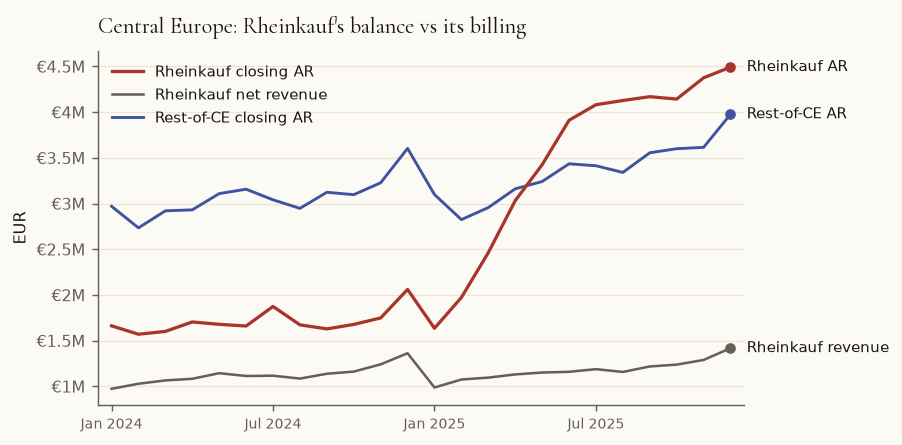

Rheinkauf closing AR: €2.1M (Dec-24) -> €4.5M (Dec-25), a build of €2.4M.
Central Europe closing AR: €5.7M (Dec-24) -> €8.5M (Dec-25).
SS E receivables anchors passed (Rheinkauf and Central Europe, Dec-24 and Dec-25).


In [11]:
# Chart 6 -- EUR: Rheinkauf closing AR monthly (Wine), Rheinkauf monthly net revenue
# (Grey, flat), rest-of-CE AR (Indigo). Legend + end labels.
rheinkauf_ar = receivables_by_customer[receivables_by_customer.customer == "Rheinkauf Gruppe"] \
    .set_index("month")["receivables_closing"].sort_index()
rheinkauf_rev = customer_revenue[(customer_revenue.customer == "Rheinkauf Gruppe")
                                  & (customer_revenue.bu == "Central Europe")] \
    .set_index("month")["net_revenue"].sort_index()
ce_ar_total = working_capital[working_capital.bu == "Central Europe"] \
    .set_index("month")["receivables_closing"].sort_index()
rest_ce_ar = ce_ar_total - rheinkauf_ar

r_months = rheinkauf_ar.index.tolist()
xr = list(range(len(r_months)))

fig, ax = new_fig()
ax.plot(xr, rheinkauf_ar.values, color=WINE, linewidth=1.8, label="Rheinkauf closing AR", zorder=4)
ax.plot(xr, rheinkauf_rev.values, color=GREY, linewidth=1.4, label="Rheinkauf net revenue", zorder=2)
ax.plot(xr, rest_ce_ar.values, color=INDIGO, linewidth=1.6, label="Rest-of-CE closing AR", zorder=3)

end_label(ax, xr[-1], rheinkauf_ar.values[-1], "Rheinkauf AR", WINE)
end_label(ax, xr[-1], rheinkauf_rev.values[-1], "Rheinkauf revenue", GREY)
end_label(ax, xr[-1], rest_ce_ar.values[-1], "Rest-of-CE AR", INDIGO)

ax.set_ylabel("EUR")
ax.yaxis.set_major_formatter(FuncFormatter(eur_fmt))
month_tick_setup(ax, r_months)
style_title(ax, "Central Europe: Rheinkauf's balance vs its billing")
ax.legend(loc="upper left", frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

rheinkauf_ar_dec24, rheinkauf_ar_dec25 = rheinkauf_ar.loc["2024-12"], rheinkauf_ar.loc["2025-12"]
ce_ar_dec24, ce_ar_dec25 = ce_ar_total.loc["2024-12"], ce_ar_total.loc["2025-12"]
rheinkauf_build = rheinkauf_ar_dec25 - rheinkauf_ar_dec24
print(f"Rheinkauf closing AR: {eur_fmt(rheinkauf_ar_dec24)} (Dec-24) -> {eur_fmt(rheinkauf_ar_dec25)} (Dec-25), "
      f"a build of {eur_fmt(rheinkauf_build)}.")
print(f"Central Europe closing AR: {eur_fmt(ce_ar_dec24)} (Dec-24) -> {eur_fmt(ce_ar_dec25)} (Dec-25).")

assert abs(rheinkauf_ar_dec24 - 2_060_367.33) < EUR_TOL
assert abs(rheinkauf_ar_dec25 - 4_493_176.80) < EUR_TOL
assert abs(ce_ar_dec24 - 5_664_104.91) < EUR_TOL
assert abs(ce_ar_dec25 - 8_470_058.75) < EUR_TOL
print("SS E receivables anchors passed (Rheinkauf and Central Europe, Dec-24 and Dec-25).")

The balance nearly triples; the grey line -- Rheinkauf's own monthly billing -- barely
moves. This is not a growing customer paying slowly on more volume; it is the same
volume, paid for later. The evidence sits in the AR-by-customer appendix, the table
nobody reads in a standard pack, and it names the account directly rather than leaving
it as an inference from Central Europe's concentration.

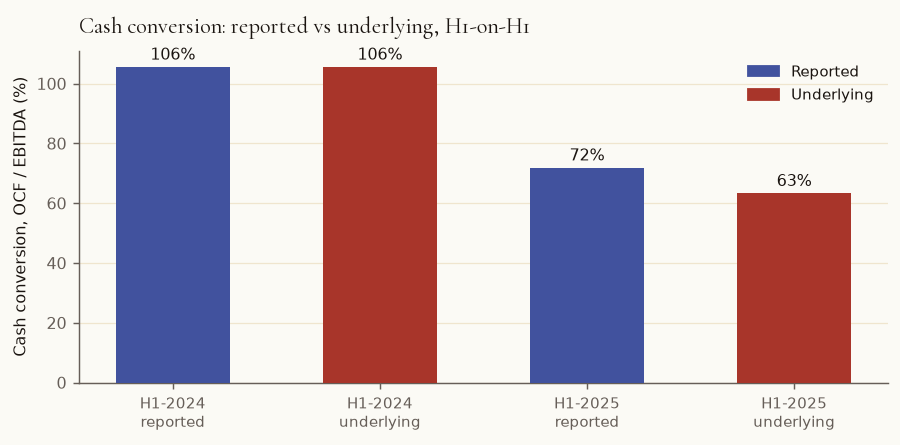

H1-2024: 105.6% (no one-offs). H1-2025: 71.9% reported, 63.3% underlying.


In [12]:
# Chart 7 -- cash conversion, H1-2024 vs H1-2025, reported (Indigo) vs underlying
# (Wine): four bars, single % axis, direct labels.
warehouse_gain_eur = 2_200_000.0

h1_24 = [m for m in months_sorted if m.startswith("2024") and m <= "2024-06"]
h1_25 = [m for m in months_sorted if m.startswith("2025") and m <= "2025-06"]
cash_i = cash.set_index("month")

ebitda_h1_24 = ebitda_reported_by_month.loc[h1_24].sum()
ocf_h1_24 = cash_i.loc[h1_24, "operating_cash_flow"].sum()
conv_h1_24_reported = ocf_h1_24 / ebitda_h1_24 * 100
conv_h1_24_underlying = conv_h1_24_reported  # no one-offs anywhere in H1-2024

ebitda_h1_25_reported = ebitda_reported_by_month.loc[h1_25].sum()
ebitda_h1_25_underlying = ebitda_h1_25_reported - warehouse_gain_eur
ocf_h1_25_reported = cash_i.loc[h1_25, "operating_cash_flow"].sum()
ocf_h1_25_underlying = ocf_h1_25_reported - warehouse_gain_eur
conv_h1_25_reported = ocf_h1_25_reported / ebitda_h1_25_reported * 100
conv_h1_25_underlying = ocf_h1_25_underlying / ebitda_h1_25_underlying * 100

labels = ["H1-2024\nreported", "H1-2024\nunderlying", "H1-2025\nreported", "H1-2025\nunderlying"]
vals = [conv_h1_24_reported, conv_h1_24_underlying, conv_h1_25_reported, conv_h1_25_underlying]
colors = [INDIGO, WINE, INDIGO, WINE]

fig, ax = new_fig()
xb = np.arange(4)
bars = ax.bar(xb, vals, color=colors, width=0.55, zorder=3)
for b, v in zip(bars, vals):
    ax.annotate(f"{v:.0f}%", (b.get_x() + b.get_width() / 2, v), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9, color=INK)
ax.set_xticks(xb)
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel("Cash conversion, OCF / EBITDA (%)")
style_title(ax, "Cash conversion: reported vs underlying, H1-on-H1")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=INDIGO, label="Reported"), Patch(color=WINE, label="Underlying")],
          loc="upper right", frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

print(f"H1-2024: {conv_h1_24_reported:.1f}% (no one-offs). "
      f"H1-2025: {conv_h1_25_reported:.1f}% reported, {conv_h1_25_underlying:.1f}% underlying.")
assert abs(conv_h1_24_reported - 106) < 3
assert abs(conv_h1_25_reported - 72) < 3
assert abs(conv_h1_25_underlying - 63) < 3

H1-2024 converts EBITDA to operating cash at roughly 106% (above 100%, as it should be
-- Q1 collects December's seasonal receivables peak). By H1-2025, reported conversion
has fallen to roughly 72%, and once the €2.2M warehouse gain is stripped out (booked
as other income, with the matching €5.5M proceeds sitting in investing cash flow --
every number disclosed, nothing connected) underlying conversion is roughly 63%: a fall
of about 42 percentage points. Nothing here is concealed. The one-off is real, disclosed
in two different statements exactly once each, and does its job: reported EBITDA stays
on plan and the cash balance never looks uncomfortable. The mask is attention, not
concealment -- the two lines that would connect it (the customer's AR build and the
April other-income line) sit thirty pages apart in a normal pack.

## 6. S3 — growth bought with discount, and the exhibits nobody claimed

Baltics & Poland is the engine of the company's FY2025 growth headline -- and the
growth is bought. Promotional discounting escalates through the year, three named
accounts run especially deep, and the volume response to each additional euro of
discount is fading.

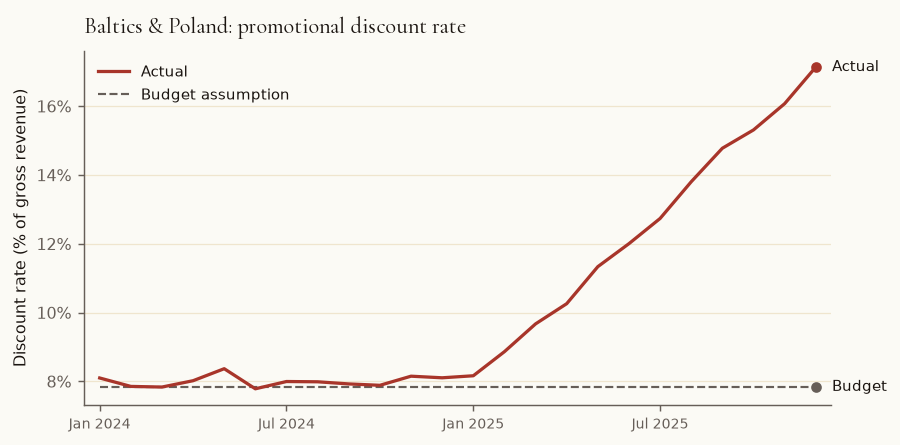

Baltics discount rate: 8.0% (FY2024 average) -> 17.1% (Dec-2025).


In [13]:
# Chart 8 -- Baltics discount rate by month, 2024-2025 (Wine), budget assumption
# (Grey dashed).
baltics = pnl[pnl.bu == "Baltics & Poland"]
baltics_budget = budget_pnl[budget_pnl.bu == "Baltics & Poland"]

disc_actual = baltics.groupby("month").apply(
    lambda d: d.promo_discounts.sum() / d.gross_revenue.sum() * 100, include_groups=False
).sort_index()
disc_budget = baltics_budget.groupby("month").apply(
    lambda d: d.promo_discounts.sum() / d.gross_revenue.sum() * 100, include_groups=False
).sort_index()

d_months = disc_actual.index.tolist()
xd = list(range(len(d_months)))

fig, ax = new_fig()
ax.plot(xd, disc_actual.values, color=WINE, linewidth=1.8, label="Actual", zorder=3)
ax.plot(xd, disc_budget.values, color=GREY, linewidth=1.2, linestyle="--", label="Budget assumption", zorder=2)
end_label(ax, xd[-1], disc_actual.values[-1], "Actual", WINE)
end_label(ax, xd[-1], disc_budget.values[-1], "Budget", GREY)

ax.set_ylabel("Discount rate (% of gross revenue)")
ax.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
month_tick_setup(ax, d_months)
style_title(ax, "Baltics & Poland: promotional discount rate")
ax.legend(loc="upper left", frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

baltics_disc_fy24 = fy(baltics, "2024").promo_discounts.sum() / fy(baltics, "2024").gross_revenue.sum() * 100
baltics_disc_dec25 = disc_actual.loc["2025-12"]
print(f"Baltics discount rate: {baltics_disc_fy24:.1f}% (FY2024 average) -> {baltics_disc_dec25:.1f}% (Dec-2025).")
assert abs(baltics_disc_fy24 - 8.00) < PCT_TOL
assert abs(baltics_disc_dec25 - 17.14) < PCT_TOL

8% to 17% -- a ladder climbed steadily across the year, not a step change a single
monthly variance would catch. Against constant unit costs, that move mechanically costs
margin: Baltics gross margin runs from roughly 41.4% (FY2024) to roughly 36.6% in the
final quarter of 2025, a fall of about 4.8 points, while BU net revenue grows about 27%
for the year and carries the company's 8.6% headline. All three storyteller runs called
this correctly as bought growth. Two exhibits the answer key designed as this story's
sharpest evidence, however, were claimed by **none of the three runs** -- shown next,
clearly separated by how each panel is computed.

**Figure 9 provenance.** Panel (a) below uses only `customer_revenue_monthly.csv` --
any reader of the public data could build it. Panel (b) needs a counterfactual ("what
would Baltics volume have been without the discount escalation?") that only exists
inside the data generator's driver model -- it is not derivable from the public CSVs
alone. The cell below therefore imports `code/generate_financials.py` (read-only: no
data is written, `data/answer_key/` is not opened) and calls its `normal_driver` and
`apply_s3` functions -- the same functions, the same computation, that
`code/validate_financials.py` uses to prove this signature exists at the designed
magnitude (rule 8c). This is the *designer's* proof the signal is in the data by
construction, not something a reader of the nine public CSVs alone could compute.

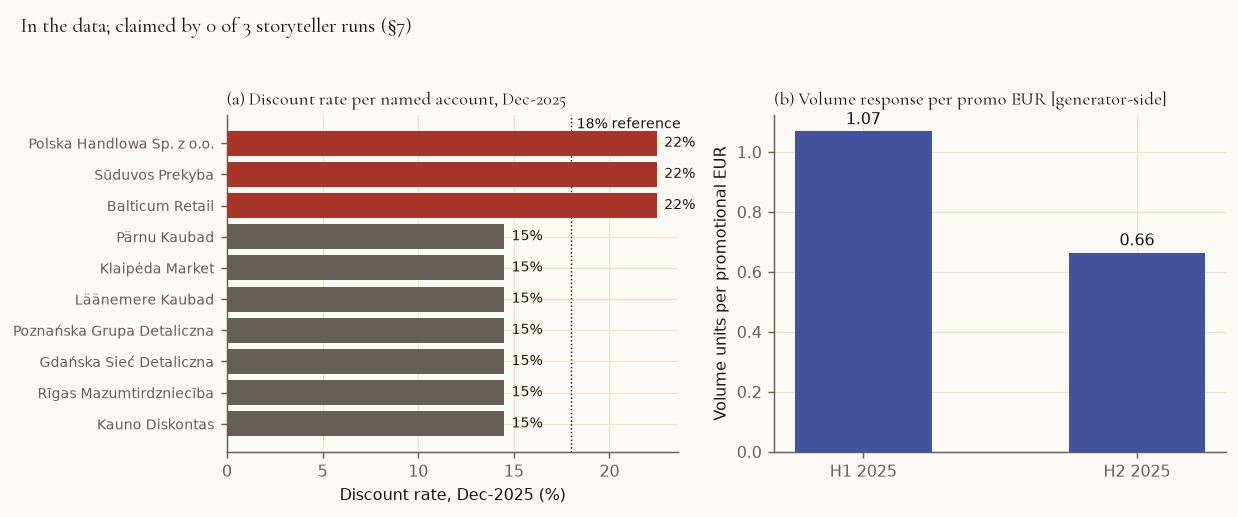

Panel (a): 3 named accounts above 18% discount in Dec-2025.
Panel (b): H1 2025 response 1.069 units/EUR, H2 2025 0.664 units/EUR -- H2 weaker by 37.8%.


In [14]:
# Chart 9 -- two-panel figure. Panel (a) is fully public-data; panel (b) is
# generator-side (see the markdown note above) and is labelled as such.
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(9.6, 3.8), dpi=DPI)
for ax in (ax_a, ax_b):
    ax.grid(axis="y" if ax is ax_b else "x", visible=False)

# --- Panel (a): Dec-2025 discount rate per named Baltics customer -- public data ---
dec_cust = customer_revenue[(customer_revenue.bu == "Baltics & Poland")
                             & (customer_revenue.month == "2025-12")
                             & (customer_revenue.customer != "Other")].copy()
dec_cust["discount_rate_pct"] = dec_cust.promo_discounts / dec_cust.gross_revenue * 100
dec_cust = dec_cust.sort_values("discount_rate_pct")
colors_a = [WINE if v > 18 else GREY for v in dec_cust["discount_rate_pct"]]

ax_a.barh(dec_cust["customer"], dec_cust["discount_rate_pct"], color=colors_a, zorder=3)
ax_a.axvline(18, color=INK, linewidth=0.8, linestyle=":", zorder=2)
ax_a.annotate("18% reference", xy=(18, len(dec_cust) - 0.4), xytext=(3, 0), textcoords="offset points",
              fontsize=7.5, color=INK, ha="left", va="center")
for i, (name, v) in enumerate(zip(dec_cust["customer"], dec_cust["discount_rate_pct"])):
    ax_a.annotate(f"{v:.0f}%", (v, i), textcoords="offset points", xytext=(4, 0),
                  fontsize=7.5, color=INK, va="center")
ax_a.set_xlabel("Discount rate, Dec-2025 (%)")
ax_a.tick_params(axis="y", labelsize=7.5)
ax_a.grid(axis="x", color=BEIGE, linewidth=0.7, zorder=0)
ax_a.set_axisbelow(True)
for spine in ("top", "right"):
    ax_a.spines[spine].set_visible(False)
ax_a.set_title("(a) Discount rate per named account, Dec-2025", fontsize=10, fontfamily=TITLE_FONT,
                color=INK, loc="left")

n_above_18 = int((dec_cust["discount_rate_pct"] > 18).sum())

# --- Panel (b): volume response per promotional euro, H1 vs H2 2025 -- generator-side
sys.path.insert(0, str(CODE_DIR))
import generate_financials as gf  # read-only: normal_driver / apply_s3 only, no writes

s3_bu = gf.config.S3_PARAMS["bu"]

def half_response(months_half):
    """Same computation as validate_financials.py's check_rule_8c_s3: the volume
    delta (story minus no-story counterfactual) per euro of incremental discount,
    summed over the half-year -- units per EUR."""
    delta_vol, delta_disc_eur = 0.0, 0.0
    for month in months_half:
        t = gf.MONTH_INDEX[month]
        for line in gf.config.LINES:
            normal = gf.normal_driver(s3_bu, line, t)
            story = gf.apply_s3(s3_bu, line, month, dict(normal))
            normal_gross = normal["volume"] * normal["price_cents"] / 100.0
            story_gross = story["volume"] * story["price_cents"] / 100.0
            delta_vol += story["volume"] - normal["volume"]
            delta_disc_eur += story_gross * story["discount_rate"] - normal_gross * normal["discount_rate"]
    return delta_vol / delta_disc_eur if delta_disc_eur else float("nan")

h1_months_gf = [m for m in gf.ACTUAL_MONTHS if "2025-01" <= m <= "2025-06"]
h2_months_gf = [m for m in gf.ACTUAL_MONTHS if "2025-07" <= m <= "2025-12"]
h1_response = half_response(h1_months_gf)
h2_response = half_response(h2_months_gf)
fade_pct = (1 - h2_response / h1_response) * 100

ax_b.bar(["H1 2025", "H2 2025"], [h1_response, h2_response], color=INDIGO, width=0.5, zorder=3)
for i, v in enumerate([h1_response, h2_response]):
    ax_b.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(0, 4),
                  ha="center", fontsize=9, color=INK)
ax_b.annotate(f"H2 ≈{fade_pct:.0f}% weaker", xy=(0.5, max(h1_response, h2_response) * 1.08),
              fontsize=8.5, color=INK, ha="center")
ax_b.set_ylabel("Volume units per promotional EUR")
ax_b.grid(axis="y", color=BEIGE, linewidth=0.7, zorder=0)
ax_b.set_axisbelow(True)
for spine in ("top", "right"):
    ax_b.spines[spine].set_visible(False)
ax_b.set_title("(b) Volume response per promo EUR [generator-side]", fontsize=10, fontfamily=TITLE_FONT,
                color=INK, loc="left")

fig.suptitle("In the data; claimed by 0 of 3 storyteller runs (§7)", fontsize=11.5,
              fontfamily=TITLE_FONT, color=INK, x=0.02, ha="left", y=1.03)
plt.tight_layout()
plt.show()

print(f"Panel (a): {n_above_18} named accounts above 18% discount in Dec-2025.")
print(f"Panel (b): H1 2025 response {h1_response:.3f} units/EUR, H2 2025 {h2_response:.3f} units/EUR "
      f"-- H2 weaker by {fade_pct:.1f}%.")
assert n_above_18 == 3
assert fade_pct >= 30

Both exhibits are provably present in the data — three accounts discounted above 18% in
December 2025, and a volume response per promotional euro roughly 38% weaker in H2 than
H1 — and neither was surfaced by any of the three storyteller runs (§7 has the detail).
The attention path the pack offered pointed at Central Europe's DSO flags, which led
every run to the AR-by-customer table; nothing in the pack pointed at discounts by
customer, and no run generated that hypothesis unprompted. Kept in as the honest ceiling
of one-pass investigation.

## 7. The storyteller layer and the marking

**Protocol.** Three independent storyteller runs (`run_01`–`run_03`), each a Claude
Code subagent (model: Claude Opus) given an identical pinned briefing
(`design/storyteller_briefing.md`) and nothing else: the nine public CSVs plus the
deterministic pack and its three companion CSVs. Runs were sequential and blinded --
each was barred from the earlier runs' outputs, and each ended its transcript with a
list of every file it opened. All three audit lists contain only permitted files; none
opened `data/answer_key/`, any design or code file, or another run's work. Mechanism
honesty: the runs executed inside a Claude Code session under a subscription plan --
no API token counts were measured and no cost figures are claimed for the agent layer.

The two tables below come entirely from the three runs' own findings files
(`data/analysis/agent_runs/run_0*_findings.json`) -- no answer key involved yet.

In [15]:
# Load the three runs' findings -- their own output, not the answer key.
runs = {}
for i in [1, 2, 3]:
    p = ANALYSIS_DIR / "agent_runs" / f"run_0{i}_findings.json"
    runs[f"run_0{i}"] = json.loads(p.read_text(encoding="utf-8"))
    print(f"  run_0{i}: {len(runs[f'run_0{i}'])} findings")

  run_01: 10 findings
  run_02: 10 findings
  run_03: 10 findings


In [16]:
# Cluster x run verdict table. The pack's flag appendix groups into six recurring
# clusters (storyteller_briefing.md); each run gives a worry/stand-down verdict per
# cluster, sometimes split across more than one finding (the worksheet's own matching
# rules accept split verdicts for C2 and C3 -- a cluster can be partly stood down on
# one measure and worried about via a different, more specific finding).
CLUSTER_NAMES = {
    1: "1. January MoM collapse (company-wide)",
    2: "2. Nordics material cost (YoY / vs budget)",
    3: "3. Baltics & Poland net revenue (YoY / vs budget)",
    4: "4. Reported EBITDA vs budget",
    5: "5. Central Europe DSO",
    6: "6. April EBITDA spike (other income)",
}

cluster_rows = []
for run_name, findings in runs.items():
    for f_ in findings:
        if f_.get("cluster"):
            cluster_rows.append({"run": run_name, "cluster": f_["cluster"], "verdict": f_["verdict"]})
cluster_df = pd.DataFrame(cluster_rows)

def join_verdicts(s):
    return " + ".join(sorted(set(s)))

cluster_pivot = cluster_df.groupby(["cluster", "run"])["verdict"].apply(join_verdicts).unstack("run")
cluster_pivot.index = [CLUSTER_NAMES[c] for c in cluster_pivot.index]
display(cluster_pivot)
print("Split verdicts (e.g. 'stand_down + worry') mean the cluster's mechanical flag "
      "was stood down while a separate, more specific finding in the same run carried "
      "the real cause -- accepted by the worksheet's own matching rules for clusters "
      "C2 and C3.")

run,run_01,run_02,run_03
1. January MoM collapse (company-wide),stand_down,stand_down,stand_down
2. Nordics material cost (YoY / vs budget),stand_down,stand_down,stand_down + worry
3. Baltics & Poland net revenue (YoY / vs budget),worry,stand_down + worry,worry
4. Reported EBITDA vs budget,worry,worry,worry
5. Central Europe DSO,worry,worry,worry
6. April EBITDA spike (other income),stand_down,stand_down,stand_down


Split verdicts (e.g. 'stand_down + worry') mean the cluster's mechanical flag was stood down while a separate, more specific finding in the same run carried the real cause -- accepted by the worksheet's own matching rules for clusters C2 and C3.


In [17]:
# Findings-count table -- volume and severity mix per run.
sev_rows = []
for run_name, findings in runs.items():
    for f_ in findings:
        sev_rows.append({"run": run_name, "severity": f_["severity"]})
sev_df = pd.DataFrame(sev_rows)
sev_counts = sev_df.pivot_table(index="run", columns="severity", aggfunc=len, fill_value=0)
sev_counts = sev_counts.reindex(columns=["info", "watch", "act"])
sev_counts["Total findings"] = sev_counts.sum(axis=1)
display(sev_counts)

severity,info,watch,act,Total findings
run,,,,
run_01,2,4,4,10
run_02,4,2,4,10
run_03,3,2,5,10


**The marking.** `data/answer_key/stories.csv` is loaded in the cell below -- the one
and only place in this notebook -- mirroring how `code/evaluate.py` itself only reads
it at evaluation time, never during the storyteller runs.

In [18]:
# The answer key -- loaded here, and only here.
answer_key = pd.read_csv(ANSWER_KEY_DIR / "stories.csv")
display(answer_key[["story_id", "type", "name", "months", "designed_magnitude"]])

,story_id,type,name,months,designed_magnitude
0,S1,story,The mix shift that reads as input inflation,2025-02..2025-12,"BU material spend +12%±1 YoY, unit material co..."
1,S2,story,The DSO creep behind a one-off,2025-01..2025-06,"BU DSO +15 days or more, company DSO +4 days o..."
2,S3,story,Growth bought with discount,2025-01..2025-12,"Discount rate 8%->17% of gross, 3+ accounts >1..."
3,S4,story,The January cliff that isn't (the trap),2025-01,Company seasonal index (per-year basis): Decem...
4,N1,noise,Logistics cost spike — winter storms; one mont...,2024-02,"EUR 80,000"
5,N2,noise,One-off recruitment and advisory costs in admin.,2024-09,"EUR 90,000"
6,N3,noise,Contractual price indexation — +2% list prices...,2025-07,list price x1.02
7,N4,noise,Structural budget optimism,2024-01..2025-12,"FY2024 (story-free year): net revenue ~-1%, gr..."


In [19]:
# Scorecard -- reproduced exactly as data/analysis/report.md states it (the
# project lead's adjudicated read of all three runs against the answer key above;
# mechanical matching alone under-reads causal language, so this table is a human
# adjudication, not a re-derivation).
scorecard = pd.DataFrame([
    ["S1 mix-shift-as-inflation -- detected, cause correct",              "OK", "OK", "OK"],
    ["S2 DSO creep -- detected, customer named, mask linked",             "OK", "OK", "OK"],
    ["S3 bought growth -- detected, cause correct",                       "OK", "OK", "OK"],
    ["S3 evidence bar: concentrated accounts named",                      "--", "--", "--"],
    ["S3 evidence bar: fading elasticity cited",                          "--", "--", "--"],
    ["S4 January trap -- de-escalated",                                   "OK", "OK", "OK"],
    ["N4 budget optimism -- noted (bonus)",                               "--", "OK", "--"],
    ["False positives (severity >= watch, post-adjudication)",             "0",  "0",  "0"],
    ["Incorrect cited figures (post-adjudication)",                        "0",  "0",  "0"],
], columns=["Designed item", "run_01", "run_02", "run_03"]).set_index("Designed item")
display(scorecard)
print("Source: data/analysis/report.md (adjudicated scorecard). 'OK' = achieved, "
      "'--' = not achieved. All six briefed flag clusters received the designed "
      "verdict in all three runs; zero false positives and zero incorrect cited "
      "figures survived adjudication across all thirty findings.")

,run_01,run_02,run_03
Designed item,,,
"S1 mix-shift-as-inflation -- detected, cause correct",OK,OK,OK
"S2 DSO creep -- detected, customer named, mask linked",OK,OK,OK
"S3 bought growth -- detected, cause correct",OK,OK,OK
S3 evidence bar: concentrated accounts named,--,--,--
S3 evidence bar: fading elasticity cited,--,--,--
S4 January trap -- de-escalated,OK,OK,OK
N4 budget optimism -- noted (bonus),--,OK,--
"False positives (severity >= watch, post-adjudication)",0,0,0
Incorrect cited figures (post-adjudication),0,0,0


Source: data/analysis/report.md (adjudicated scorecard). 'OK' = achieved, '--' = not achieved. All six briefed flag clusters received the designed verdict in all three runs; zero false positives and zero incorrect cited figures survived adjudication across all thirty findings.


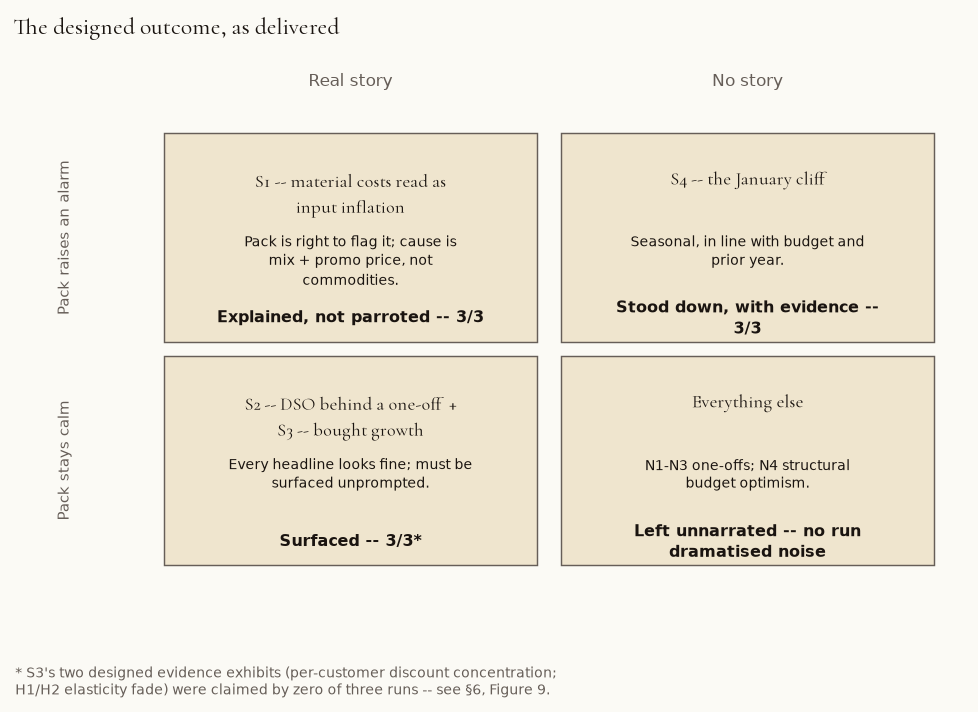

In [20]:
# Figure 10 -- the designed-outcome 2x2, styled as a matplotlib figure. Cell text is
# pre-wrapped with textwrap (matplotlib's own wrap=True is not confined to a cell's
# width and will bleed text into the neighbouring cell).
import textwrap

def wrap(text, width):
    return "\n".join(textwrap.wrap(text, width=width))

fig, ax = plt.subplots(figsize=(7.6, 5.5), dpi=DPI)
ax.set_xlim(-0.35, 2.05)
ax.set_ylim(-0.30, 2.30)
ax.axis("off")

cells_2x2 = {
    (0, 1): ("S1 -- material costs read as input inflation",
             "Pack is right to flag it; cause is mix + promo price, not commodities.",
             "Explained, not parroted -- 3/3"),
    (1, 1): ("S4 -- the January cliff",
             "Seasonal, in line with budget and prior year.",
             "Stood down, with evidence -- 3/3"),
    (0, 0): ("S2 -- DSO behind a one-off  +  S3 -- bought growth",
             "Every headline looks fine; must be surfaced unprompted.",
             "Surfaced -- 3/3*"),
    (1, 0): ("Everything else",
             "N1-N3 one-offs; N4 structural budget optimism.",
             "Left unnarrated -- no run dramatised noise"),
}

for (col, row), (title, sub, outcome) in cells_2x2.items():
    x0, y0 = col, row
    ax.add_patch(Rectangle((x0 + 0.03, y0 + 0.03), 0.94, 0.94, facecolor=BEIGE,
                            edgecolor=GREY, linewidth=0.8, zorder=1))
    ax.text(x0 + 0.5, y0 + 0.82, wrap(title, 30), ha="center", va="top", fontsize=10,
            fontfamily=TITLE_FONT, color=INK, zorder=2, linespacing=1.3)
    ax.text(x0 + 0.5, y0 + 0.52, wrap(sub, 34), ha="center", va="top", fontsize=7.6,
            color=INK, zorder=2, linespacing=1.35)
    ax.text(x0 + 0.5, y0 + 0.14, wrap(outcome, 30), ha="center", va="center", fontsize=8.8,
            color=INK, fontweight="bold", zorder=2, linespacing=1.3)

ax.text(0.5, 2.18, "Real story", ha="center", fontsize=9.5, color=GREY)
ax.text(1.5, 2.18, "No story", ha="center", fontsize=9.5, color=GREY)
ax.text(-0.22, 1.5, "Pack raises an alarm", ha="center", va="center", fontsize=8.5, color=GREY, rotation=90)
ax.text(-0.22, 0.5, "Pack stays calm", ha="center", va="center", fontsize=8.5, color=GREY, rotation=90)

ax.set_title("The designed outcome, as delivered", fontsize=13, fontfamily=TITLE_FONT,
              color=INK, loc="left", pad=14)
fig.text(0.02, 0.015,
         "* S3's two designed evidence exhibits (per-customer discount concentration;\n"
         "H1/H2 elasticity fade) were claimed by zero of three runs -- see §6, Figure 9.",
         fontsize=7.5, color=GREY, ha="left", va="bottom")
plt.tight_layout(rect=[0, 0.075, 1, 1])
plt.show()

## 8. What a board does with this

**Three actions.** Discount policy in Baltics & Poland: the 2025 escalation
gave away about €5.9M of gross profit against holding 2024 rates, and the volume
it bought responds less and less (§6, Figure 9b). Baltics & Poland is buying growth at a rate that is becoming less efficient,
not more. Baltics & Poland cost-to-grow: gross margin there has fallen from roughly
41.4% to roughly 36.6% in the most recent quarter (§6) while net revenue carries the
company's headline growth number -- a board reading "revenue +8.6%, ahead of plan"
needs to see the margin line in the same sentence. The Rheinkauf receivable: Central
Europe's largest account is carrying roughly €2.4M more in outstanding balance than a
year ago on essentially flat billing (§5) -- a receivable a lender or an acquirer's due
diligence would find, surfaced here twelve months earlier.

**Three stand-downs.** January's MoM collapse is seasonal, in line with budget and
prior year, in both years -- no action (§3). The Nordics material-cost flag is not a
procurement problem -- unit costs are flat; redirect attention to promotional pricing
and mix, where the margin is actually leaking (§4). The April EBITDA spike is a
disclosed one-off (warehouse sale-and-leaseback), not a step-change in the business --
correctly identified and set aside by every run (§5, §7).

**The honest misses.** Two of the four stories' hardest evidence exhibits went
unclaimed: S3's per-customer discount concentration and H1/H2 elasticity fade were both
provably present in the data (§6, Figure 9) and found by none of the three runs; N4
(structural budget optimism) was found by only one of three. Nobody generated the
discounts-by-customer hypothesis unprompted, and only one run separated "the budget
always runs a little hot" from "2025 got worse". These are not failures of the
approach so much as the reason it needs one: a single unmarked run would have reported
three strong findings and no visibility into what it missed. The case for an evaluation
harness is exactly this gap -- not that the storyteller layer is unreliable, but that
without a held-out answer key nobody would know where its ceiling sits.

## 9. Reproducibility

Everything above regenerates byte-identically from seed 42. Run from
`Case Studies/05 Board Reporting/`:

```
python code/generate_financials.py     # the ten data tables + data/answer_key/stories.csv
python code/validate_financials.py     # all 12 coherence rules; exits 1 on any failure
python code/variance_analysis.py       # the deterministic pack: surface_report.md + 3 CSVs
# three Claude Code subagent runs, pinned briefing design/storyteller_briefing.md ->
#   data/analysis/agent_runs/run_0{1,2,3}_findings.json + memos
python code/evaluate.py                # mechanical worksheet -> evaluation_worksheet.md
#   (data/analysis/report.md is the project lead's adjudicated scorecard, written by
#   hand after reading the worksheet end to end -- not machine-generated)
```

Every tunable -- the company grid, all driver levels and trends, the seasonal indices,
noise sigmas, the four story injections, the noise-ledger events, and the budget
assumptions -- lives in `code/config.py`. Design rationale and the as-built calibration
notes are in `design/design.md`; the build log, including every correction made during
review, is in `design/DECISIONS.md`.

| Artefact | Location |
|---|---|
| Design doc | `design/design.md` |
| Decision log | `design/DECISIONS.md` |
| Generation code + config | `code/` |
| Generated dataset | `data/*.csv` |
| Answer key (held out) | `data/answer_key/stories.csv` |
| Deterministic pack | `data/analysis/surface_report.md` + companion CSVs |
| Storyteller runs | `data/analysis/agent_runs/` |
| Mechanical evaluation | `data/analysis/evaluation_worksheet.md`, `evaluation_scores.csv` |
| Adjudicated scorecard | `data/analysis/report.md` |
| This notebook | `notebooks/board_reporting.ipynb` |